<a href="https://colab.research.google.com/github/saivigneshmuthyam1/Celebal-Excellence-Internship/blob/main/week6_SaiVignesh_Muthyam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Build a deep learning model that can remove noise from images using an autoencoder on MNIST

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

print(f"TensorFlow Version: {tf.__version__}")

gpu_available = len(tf.config.list_physical_devices('GPU')) > 0
print(f"GPU Available: {gpu_available}")

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow Version: 2.20.0
GPU Available: True


### Differentiating Noise Type and Model Architecture

To make this project distinct(as MNIST have very less noise), we'll introduce **Salt-and-Pepper noise** instead of just Gaussian noise, providing a different challenge for the autoencoder. Furthermore, the autoencoder's architecture will be enhanced with **Batch Normalization** layers for better training performance and regularization. We'll also use `Conv2D` with `strides` for downsampling and `Conv2DTranspose` for upsampling, offering an alternative to `MaxPooling2D` and `UpSampling2D`.

In [15]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/mnist-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path to dataset files: /kaggle/input/mnist-dataset


In [16]:
import pandas as pd
import os

train_file_path = '/content/sample_data/mnist_train_small.csv'
test_file_path = '/content/sample_data/mnist_test.csv'

train_df = pd.read_csv(train_file_path, header=None)
test_df = pd.read_csv(test_file_path, header=None)

y_train = train_df.iloc[:, 0].values
x_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Normalize pixels
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"x_train pixel min: {x_train.min()}, max: {x_train.max()}")
print(f"x_test pixel min: {x_test.min()}, max: {x_test.max()}")

x_train shape: (20000, 28, 28, 1)
y_train shape: (20000,)
x_test shape: (10000, 28, 28, 1)
y_test shape: (10000,)
x_train pixel min: 0.0, max: 1.0
x_test pixel min: 0.0, max: 1.0


In [17]:
NOISE_FACTOR = 0.5

x_train_noisy = x_train + NOISE_FACTOR * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + NOISE_FACTOR * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print(f"x_train_noisy pixel min: {x_train_noisy.min()}, max: {x_train_noisy.max()}")
print(f"x_test_noisy pixel min: {x_test_noisy.min()}, max: {x_test_noisy.max()}")

x_train_noisy pixel min: 0.0, max: 1.0
x_test_noisy pixel min: 0.0, max: 1.0


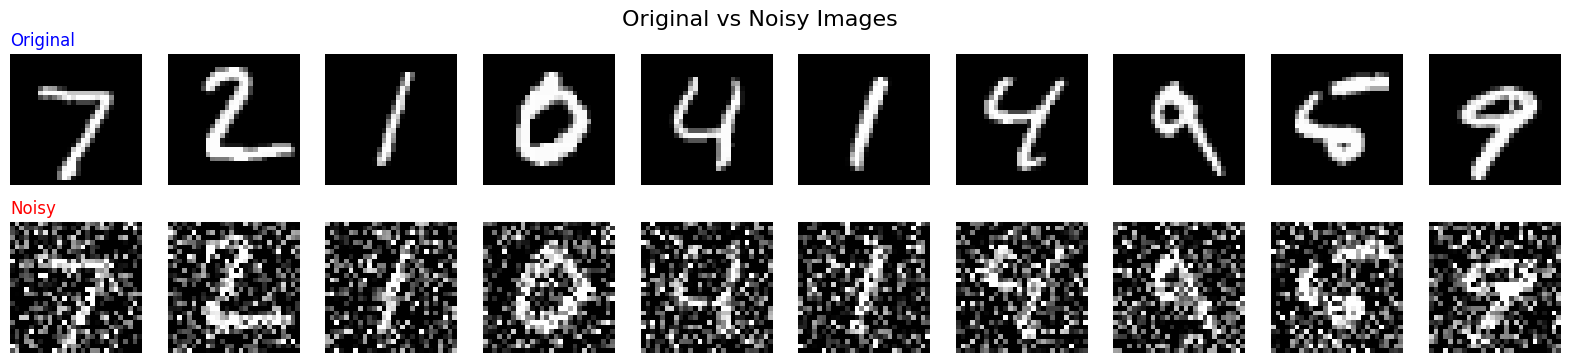

In [18]:
n = 10
plt.figure(figsize=(20, 4))
plt.suptitle('Original vs Noisy Images', fontsize=16)

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('Original', loc='left', color='blue')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('Noisy', loc='left', color='red')

plt.savefig('original_vs_noisy_images.png')
plt.show()

In [19]:
def build_denoising_autoencoder():
    input_img = keras.Input(shape=(28, 28, 1), name='input')

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)

    # Bottleneck
    bottleneck = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='bottleneck')(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='dec_conv1')(bottleneck)
    x = layers.UpSampling2D((2, 2), name='dec_upsample1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='dec_upsample2')(x)

    # Output layer
    output_img = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output')(x)

    # Create the model
    autoencoder = Model(input_img, output_img, name='denoising_autoencoder')
    return autoencoder

autoencoder = build_denoising_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv2D)             │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling2D)    │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,625 (1.20 MB)

 Trainable params: 314,625 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                    loss='binary_crossentropy',
                    metrics=['mse'])

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

EPOCHS = 50
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=callbacks
)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.2000 - mse: 0.0449 - val_loss: 0.1272 - val_mse: 0.0212 - learning_rate: 0.0010
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1165 - mse: 0.0177 - val_loss: 0.1100 - val_mse: 0.0154 - learning_rate: 0.0010
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1083 - mse: 0.0150 - val_loss: 0.1065 - val_mse: 0.0142 - learning_rate: 0.0010
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1045 - mse: 0.0137 - val_loss: 0.1023 - val_mse: 0.0130 - learning_rate: 0.0010
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1022 - mse: 0.0130 - val_loss: 0.1005 - val_mse: 0.0125 - learning_rate: 0.0010
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1005 - mse: 0.0125 - val_loss: 0.0994 - val_mse: 0.0121 - learning_rate: 0.0010
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0993 - mse: 0.0121 - val_loss: 0.0985 - val_mse: 0.0118 - learning_rate: 0.001

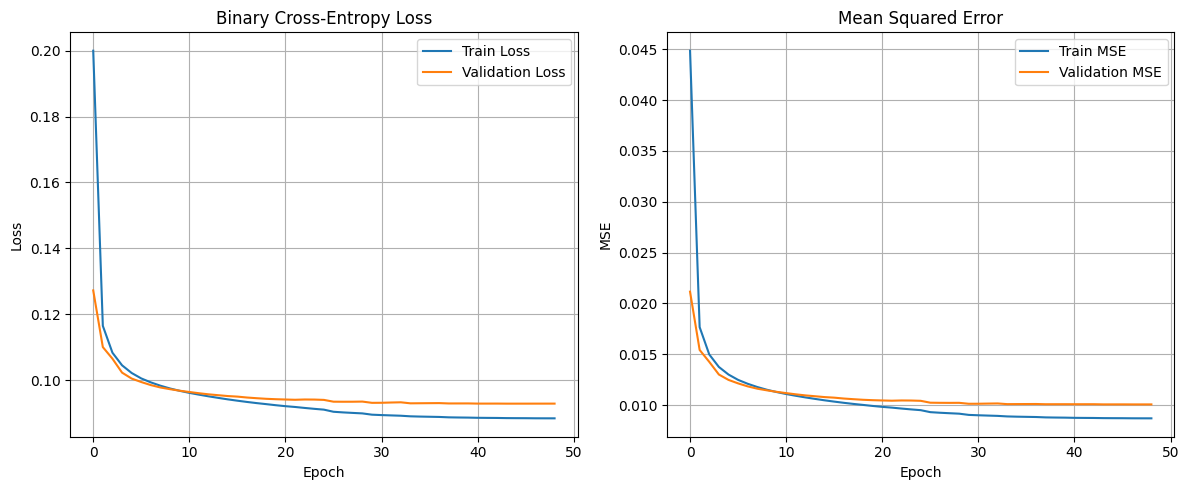

Final Validation Loss: 0.0929
Final Validation MSE: 0.0101


In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Binary Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mse'], label='Train MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.title('Mean Squared Error')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

final_val_loss = history.history['val_loss'][-1]
final_val_mse = history.history['val_mse'][-1]

print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation MSE: {final_val_mse:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Denoised images shape: (10000, 28, 28, 1)
Denoised images pixel min: 1.9280432878363138e-15, max: 0.9992559552192688


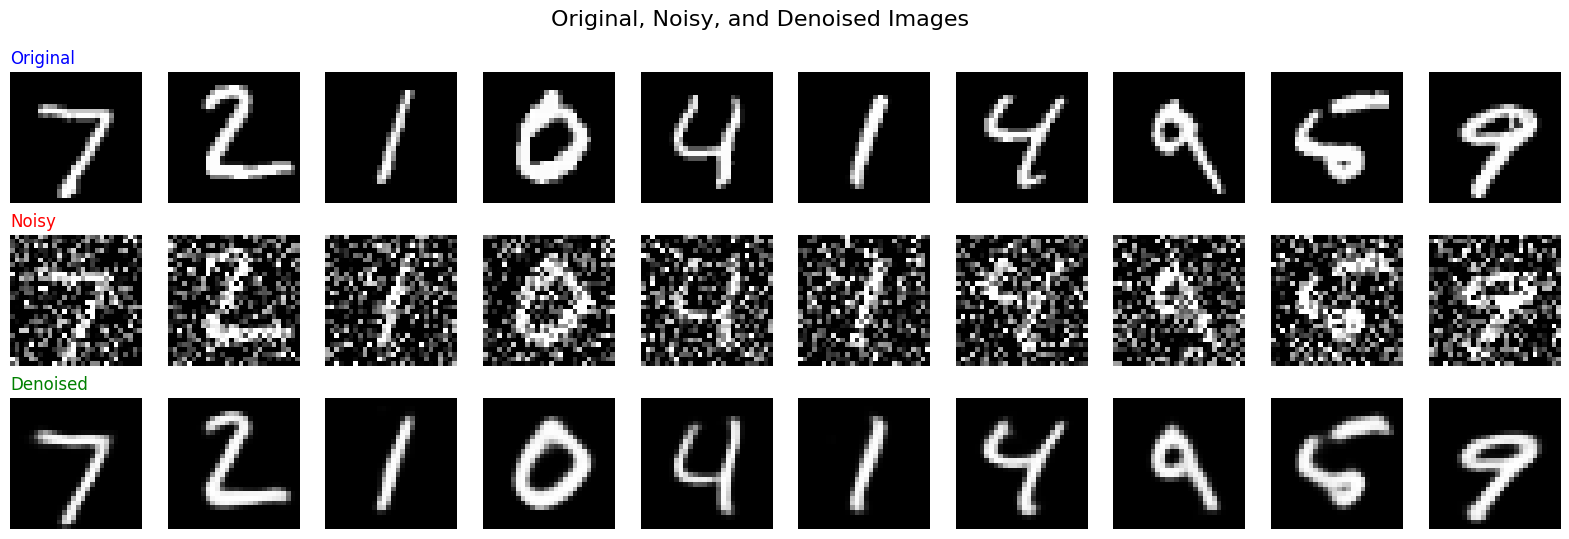

In [22]:
denoised_images = autoencoder.predict(x_test_noisy)

print(f"Denoised images shape: {denoised_images.shape}")
print(f"Denoised images pixel min: {denoised_images.min()}, max: {denoised_images.max()}")

n = 10
plt.figure(figsize=(20, 6))
plt.suptitle('Original, Noisy, and Denoised Images', fontsize=16)

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('Original', loc='left', color='blue')

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('Noisy', loc='left', color='red')

    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    if i == 0:
        ax.set_title('Denoised', loc='left', color='green')

plt.savefig('denoising_autoencoder_results.png')
plt.show()

In [23]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_metrics(original, compared, label):
    psnr_values = []
    ssim_values = []
    for i in range(len(original)):
        psnr_values.append(psnr(original[i].squeeze(), compared[i].squeeze(), data_range=1))
        ssim_values.append(ssim(original[i].squeeze(), compared[i].squeeze(), data_range=1))

    avg_psnr = np.mean(psnr_values)
    avg_ssim = np.mean(ssim_values)
    print(f"Average PSNR ({label} vs Clean): {avg_psnr:.4f}")
    print(f"Average SSIM ({label} vs Clean): {avg_ssim:.4f}")
    return avg_psnr, avg_ssim

print("\n Metrics for Noisy Images")
avg_psnr_noisy, avg_ssim_noisy = compute_metrics(x_test, x_test_noisy, 'Noisy')

print("\n Metrics for Denoised Images")
avg_psnr_denoised, avg_ssim_denoised = compute_metrics(x_test, denoised_images, 'Denoised')

psnr_improvement = avg_psnr_denoised - avg_psnr_noisy
ssim_improvement = avg_ssim_denoised - avg_ssim_noisy

print(f"\nNet PSNR Improvement: {psnr_improvement:.4f}")
print(f"Net SSIM Improvement: {ssim_improvement:.4f}")


 Metrics for Noisy Images
Average PSNR (Noisy vs Clean): 9.3821
Average SSIM (Noisy vs Clean): 0.3753

 Metrics for Denoised Images
Average PSNR (Denoised vs Clean): 20.3520
Average SSIM (Denoised vs Clean): 0.8797

Net PSNR Improvement: 10.9699
Net SSIM Improvement: 0.5044


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


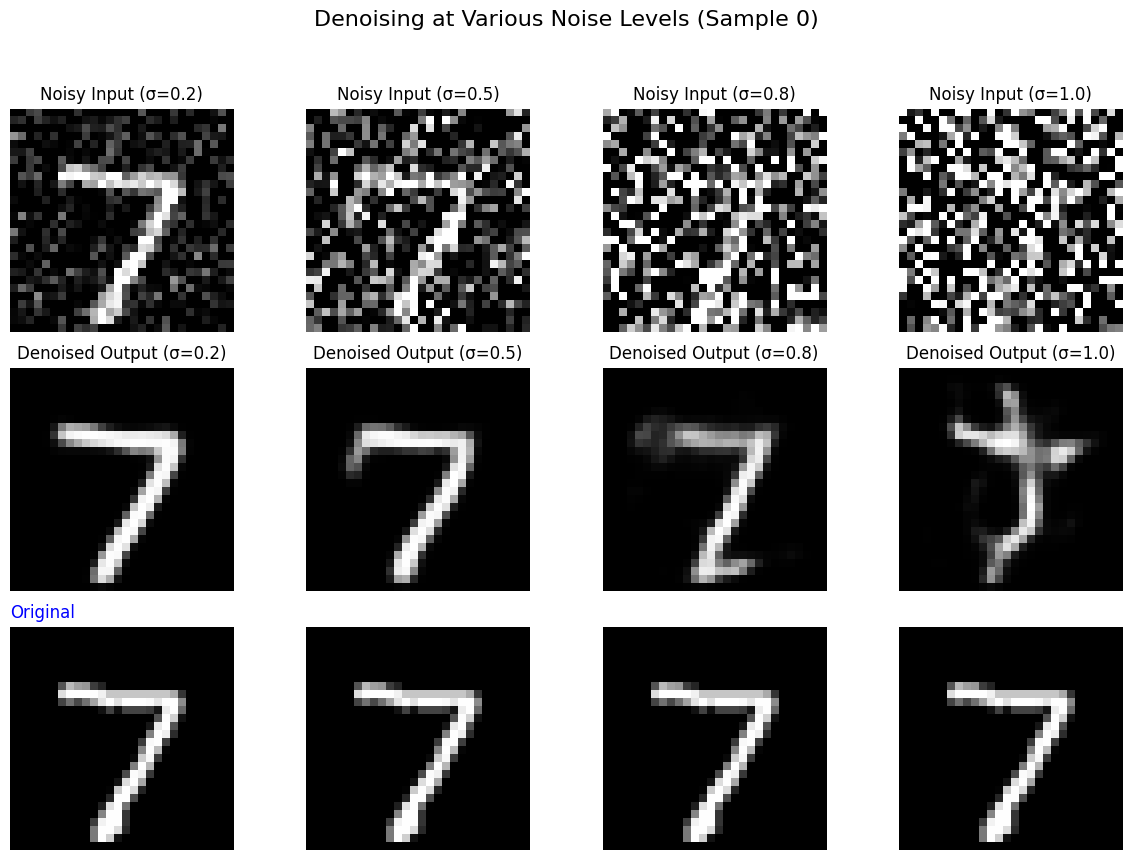

In [24]:
sample_idx = 0
original_image = x_test[sample_idx]
noise_levels = [0.2, 0.5, 0.8, 1.0]

plt.figure(figsize=(len(noise_levels) * 3, 9))
plt.suptitle('Denoising at Various Noise Levels (Sample 0)', fontsize=16)

for i, noise_factor in enumerate(noise_levels):
    noisy_input = original_image + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=original_image.shape)
    noisy_input = np.clip(noisy_input, 0.0, 1.0)

    denoised_output = autoencoder.predict(np.expand_dims(noisy_input, axis=0))

    ax = plt.subplot(3, len(noise_levels), i + 1)
    plt.imshow(noisy_input.squeeze(), cmap='gray')
    plt.title(f'Noisy Input (σ={noise_factor})')
    plt.axis('off')

    ax = plt.subplot(3, len(noise_levels), i + 1 + len(noise_levels))
    plt.imshow(denoised_output.squeeze(), cmap='gray')
    plt.title(f'Denoised Output (σ={noise_factor})')
    plt.axis('off')

    ax = plt.subplot(3, len(noise_levels), i + 1 + 2 * len(noise_levels))
    plt.imshow(original_image.squeeze(), cmap='gray')
    if i == 0:
        ax.set_title('Original', loc='left', color='blue')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('denoising_at_various_noise_levels.png')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Latent space shape: (1, 7, 7, 128)


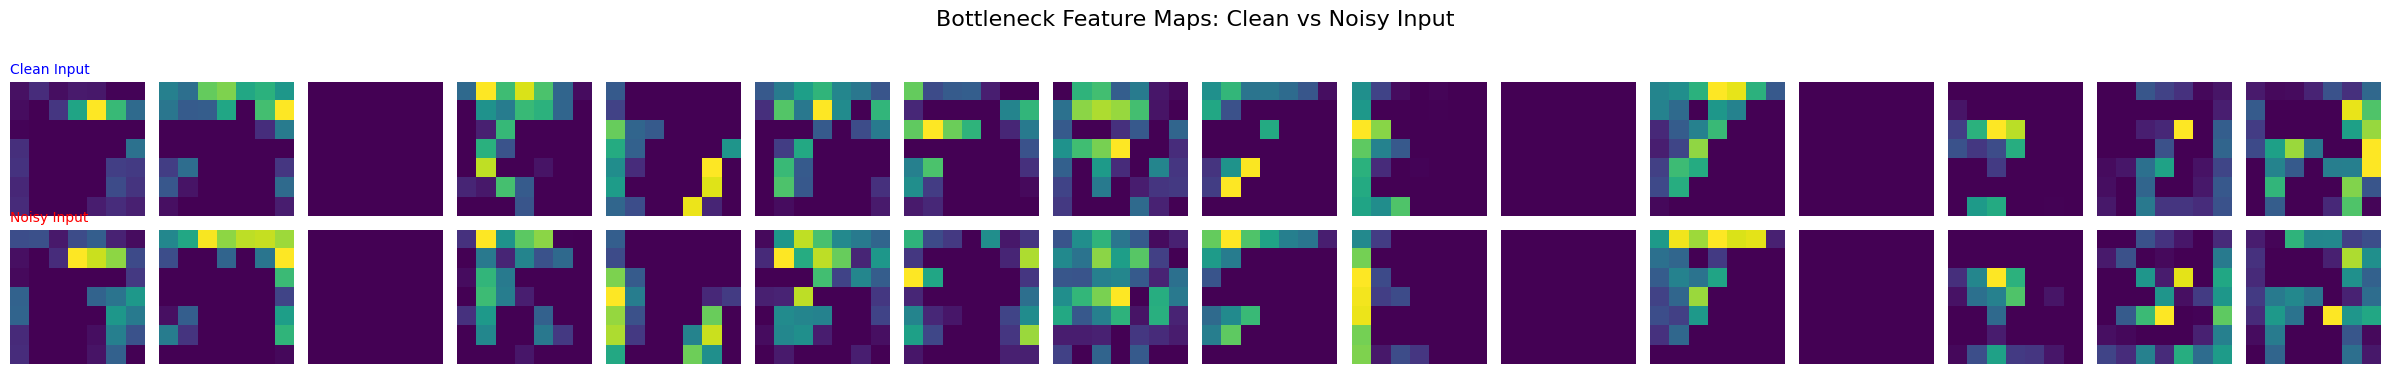

In [25]:
encoder_model = Model(autoencoder.input, autoencoder.get_layer('bottleneck').output, name='Encoder')

sample_idx = 0
original_image_for_latent = np.expand_dims(x_test[sample_idx], axis=0)
noisy_image_for_latent = np.expand_dims(x_test_noisy[sample_idx], axis=0)

clean_latent_representation = encoder_model.predict(original_image_for_latent)
noisy_latent_representation = encoder_model.predict(noisy_image_for_latent)

print(f"Latent space shape: {clean_latent_representation.shape}")

n_features_to_plot = 16
fig, axes = plt.subplots(2, n_features_to_plot, figsize=(n_features_to_plot * 1.5, 4))
fig.suptitle('Bottleneck Feature Maps: Clean vs Noisy Input', fontsize=16)

for i in range(n_features_to_plot):
    ax = axes[0, i]
    ax.imshow(clean_latent_representation[0, :, :, i], cmap='viridis')
    ax.axis('off')
    if i == 0:
        ax.set_title('Clean Input', loc='left', color='blue', fontsize=10)

    ax = axes[1, i]
    ax.imshow(noisy_latent_representation[0, :, :, i], cmap='viridis')
    ax.axis('off')
    if i == 0:
        ax.set_title('Noisy Input', loc='left', color='red', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('bottleneck_feature_maps.png')
plt.show()

### Cell 12: Model Export

In [26]:
# Save the trained autoencoder model
model_save_path = 'denoising_autoencoder_mnist.keras'
autoencoder.save(model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: denoising_autoencoder_mnist.keras
